# Metodologia Design Science Research (DSR)\n
\n
**Etapas de Pesquisa (Peffers et al., 2007):**\n
### 4. Demonstração (Demonstration)\n
\n
**Objetivo Acadêmico:** Este notebook aplica o modelo **ARIMA** (Auto-Regressive Integrated Moving Average) para estabelecer um benchmark estatístico clássico. Na DSR, a demonstração exige o uso do artefato para resolver instâncias do problema. Aqui, o modelo univariado testa a hipótese de que a autocorrelação temporal da demanda é suficiente para a predição, servindo como base de comparação para os modelos multivariados de Machine Learning.\n

# 07g - Modelagem Estatística: ARIMA
Neste notebook, aplicamos o modelo **ARIMA** (Auto-Regressive Integrated Moving Average). 

Diferente dos modelos de ML, o ARIMA foca na estrutura temporal de uma única variável (univariado), tentando capturar tendências e autocorrelações.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Carregamento
df = pd.read_csv('../data/base_features_selecionadas.csv')
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')
df.set_index('data', inplace=True)

TARGET = 'total_servido'
y = df[TARGET]

train_size = int(len(y) * 0.8)
train, test = y.iloc[:train_size], y.iloc[train_size:]

print(f"📦 Série temporal pronta. Estudo univariado para ARIMA.")

📦 Série temporal pronta. Estudo univariado para ARIMA.


In [2]:
# 1. Teste de Estacionariedade (Dickey-Fuller)
result = adfuller(train)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] <= 0.05:
    print("Série é estacionária (d=0 pode ser suficiente)")
else:
    print("Série NÃO é estacionária (d=1 ou mais necessário)")

ADF Statistic: -2.1941
p-value: 0.2084
Série NÃO é estacionária (d=1 ou mais necessário)


🚀 Ajustando ARIMA (Walk-forward)... Este processo pode levar alguns segundos.

📊 Resultados Finais (ARIMA):


,Modelo,MAE,RMSE,R2
0,ARIMA,28.323804,36.255955,-0.022856


✅ Predições salvas em 'preds_arima.csv'


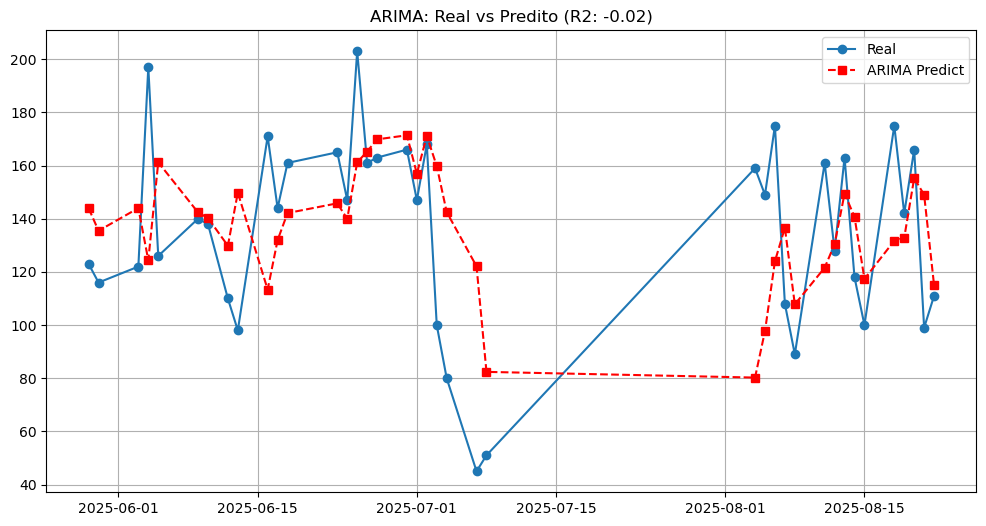

In [3]:
# 2. Modelo ARIMA (Walk-forward Validation)
from sklearn.metrics import mean_squared_error, r2_score

print("🚀 Ajustando ARIMA (Walk-forward)... Este processo pode levar alguns segundos.")
history = [x for x in train]
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test.iloc[t])

# 3. Cálculos de Métricas
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
r2 = r2_score(test, predictions)

df_res = pd.DataFrame([{
    'Modelo': 'ARIMA',
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}])

print("\n📊 Resultados Finais (ARIMA):")
display(df_res)

# 4. Salvar Predições para o Comparativo (Notebook 08)
df_preds = pd.DataFrame({
    'data': test.index,
    'real': test.values,
    'pred_arima': predictions
})
df_preds.to_csv('../data/preds_arima.csv', index=False)
print("✅ Predições salvas em 'preds_arima.csv'")

# 5. Visualização
plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label='Real', marker='o')
plt.plot(test.index, predictions, label='ARIMA Predict', color='red', linestyle='--', marker='s')
plt.title(f'ARIMA: Real vs Predito (R2: {r2:.2f})')
plt.legend()
plt.grid(True)
plt.show()